# Week 06: Business Statistics & Analytics - E-commerce Analysis

## Learning Objectives
By the end of this exercise, you will be able to:
- Calculate key business metrics using pandas
- Create meaningful visualizations for business insights
- Apply statistical concepts to real business scenarios
- Make data-driven recommendations

---

## Business Context

You're working as a Data Analyst for **TechMart**, an e-commerce company. Your manager needs insights from last quarter's sales data to inform strategic decisions for the upcoming quarter.

Your analysis will help answer critical questions about customer behavior, regional performance, and product trends that directly impact business growth.

In [1]:
# Install required packages
%pip install --upgrade pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 5.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 9.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 9.2 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.3
    Uninstalling numpy-2.3.3:
      Successfully uninstalled numpy-2.3.3
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.2
    Uninstalling pandas-2.3.2:
      Successfully uninstalled pandas-2.3.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.6
    Uninstalling matplotlib-3.10.6:
      Successfully uninstalled matplotlib-3.10.6

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the 

## Dataset Setup

First, let's generate the synthetic dataset you'll be analyzing:

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducible results
np.random.seed(42)

# Generate 500 orders from 2023
n_orders = 500

# Create order IDs and customer data
order_id = np.arange(1, n_orders + 1)
customer_id = np.random.randint(1, 101, size=n_orders)
customer_segment = np.random.choice(["Student", "Professional", "Senior"], size=n_orders, p=[0.4, 0.4, 0.2])
region = np.random.choice(["North", "South", "East", "West"], size=n_orders)
order_date = pd.date_range(start="2023-01-01", periods=n_orders, freq="D")
product_category = np.random.choice(["Electronics", "Clothing", "Books", "Home", "Sports"], size=n_orders)
quantity = np.random.randint(1, 5, size=n_orders)
unit_price = np.round(np.random.uniform(10, 200, size=n_orders), 2)
revenue = quantity * unit_price
discount_applied = np.random.choice([0, 5, 10, 15, 20, 25, 30], size=n_orders, p=[0.5,0.1,0.1,0.1,0.05,0.05,0.1])
payment_method = np.random.choice(["Credit Card", "PayPal", "Gift Card", "Debit Card"], size=n_orders)

# Build dataframe
df = pd.DataFrame({
    "order_id": order_id,
    "customer_id": customer_id,
    "customer_segment": customer_segment,
    "region": region,
    "order_date": order_date,
    "product_category": product_category,
    "quantity": quantity,
    "unit_price": unit_price,
    "revenue": revenue,
    "discount_applied": discount_applied,
    "payment_method": payment_method
})

# Save dataset for reference
df.to_csv("ecommerce_data.csv", index=False)
print("Dataset created successfully!")

# Display first few rows
df.head()

Dataset created successfully!


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


## Data Exploration

Let's start by understanding our dataset:

In [3]:
# Load the data
data = pd.read_csv("ecommerce_data.csv")

# Basic information about the dataset
print("Dataset Info:")
print(data.info())
print("\nDataset Shape:", data.shape)
print("\nFirst few rows:")
data.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          500 non-null    int64  
 1   customer_id       500 non-null    int64  
 2   customer_segment  500 non-null    object 
 3   region            500 non-null    object 
 4   order_date        500 non-null    object 
 5   product_category  500 non-null    object 
 6   quantity          500 non-null    int64  
 7   unit_price        500 non-null    float64
 8   revenue           500 non-null    float64
 9   discount_applied  500 non-null    int64  
 10  payment_method    500 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 43.1+ KB
None

Dataset Shape: (500, 11)

First few rows:


,order_id,customer_id,customer_segment,region,order_date,product_category,quantity,unit_price,revenue,discount_applied,payment_method
0,1,52,Student,North,2023-01-01,Clothing,1,42.43,42.43,0,Debit Card
1,2,93,Student,West,2023-01-02,Sports,1,24.18,24.18,0,Gift Card
2,3,15,Professional,East,2023-01-03,Sports,3,158.71,476.13,0,Debit Card
3,4,72,Student,East,2023-01-04,Sports,1,60.42,60.42,0,Credit Card
4,5,61,Student,West,2023-01-05,Books,3,43.78,131.34,0,Gift Card


Monthly Revenue:
month
2023-01    6626.66
2023-02    6796.03
2023-03    8960.10
2023-04    7713.47
2023-05    7266.80
2023-06    7982.47
2023-07    7981.65
2023-08    6664.64
2023-09    9708.06
2023-10    7287.27
2023-11    8795.85
2023-12    8119.44
2024-01    7268.59
2024-02    8388.91
2024-03    6835.73
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


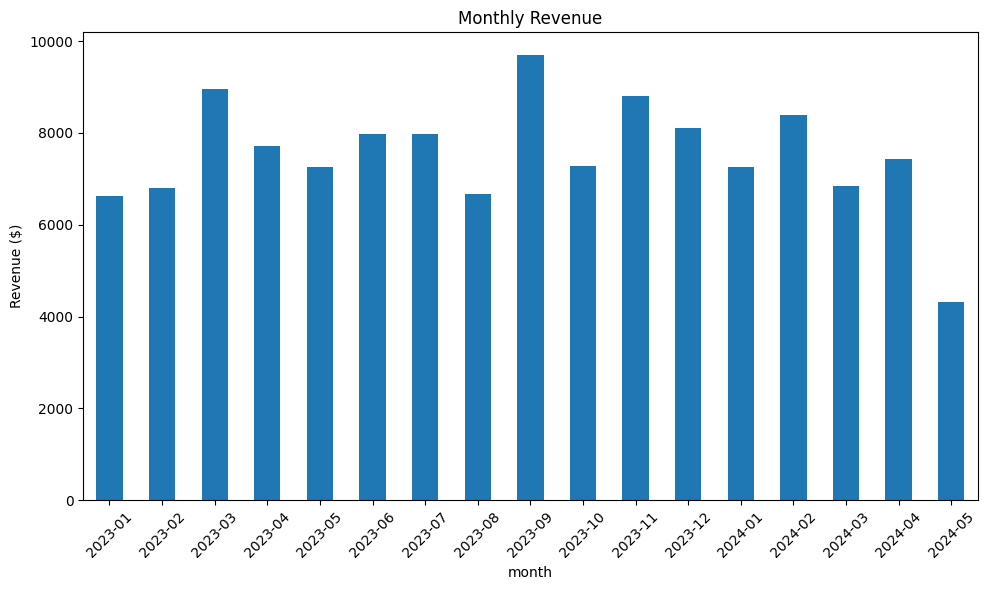

In [4]:
# Convert order_date to datetime and add helpful columns
data["order_date"] = pd.to_datetime(data["order_date"])
data["month"] = data["order_date"].dt.to_period("M")
data["day_of_week"] = data["order_date"].dt.day_name()

# Example: Revenue by month
monthly_revenue = data.groupby("month")["revenue"].sum()
print("Monthly Revenue:")
print(monthly_revenue)

# Plot monthly revenue
monthly_revenue.plot(kind="bar", figsize=(10,6), title="Monthly Revenue")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## Business Questions

Now answer each of the following business questions. Use the starter code above as a reference, and expand your analysis to solve all questions.

### 1. Revenue Overview
What was the company's total revenue last quarter? Break it down by month.

Total Revenue Last Quarter (2024Q2): $11,745.00

Monthly Revenue Breakdown (Last Quarter):
order_date
2024-04    7430.29
2024-05    4314.71
Freq: M, Name: revenue, dtype: float64


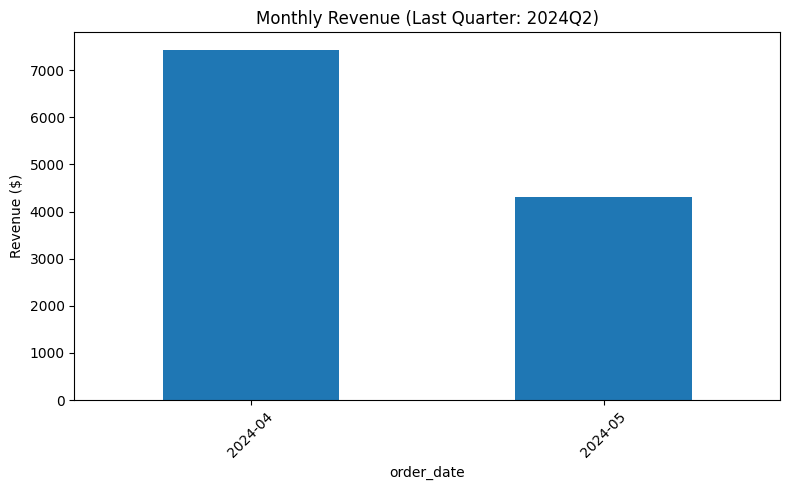

In [5]:
# Your code here

# Find the last quarter period in the data
last_date = data["order_date"].max()
last_quarter = (last_date.to_period("Q"))

# Filter data for the last quarter
last_quarter_mask = data["order_date"].dt.to_period("Q") == last_quarter
data_last_quarter = data[last_quarter_mask]

# Calculate total revenue for the last quarter
total_revenue_last_quarter = data_last_quarter["revenue"].sum()
print(f"Total Revenue Last Quarter ({last_quarter}): ${total_revenue_last_quarter:,.2f}")

# Breakdown by month
monthly_revenue_last_quarter = data_last_quarter.groupby(data_last_quarter["order_date"].dt.to_period("M"))["revenue"].sum()
print("\nMonthly Revenue Breakdown (Last Quarter):")
print(monthly_revenue_last_quarter)

# Optionally, plot the breakdown
monthly_revenue_last_quarter.plot(kind="bar", figsize=(8,5), title=f"Monthly Revenue (Last Quarter: {last_quarter})")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




### 2. Top Customers
Who are the top 5 customers by total revenue contribution?

Top 5 customers by total revenue contribution:
customer_id
62    4448.39
24    3369.44
90    2976.78
92    2838.74
97    2835.62
Name: revenue, dtype: float64


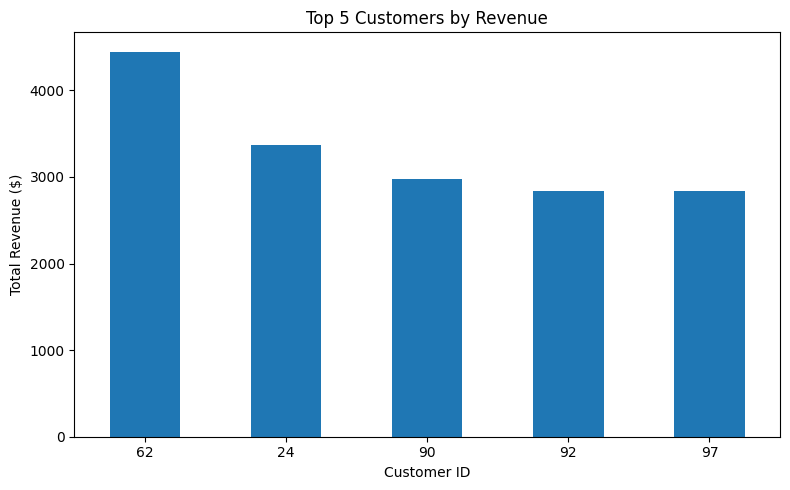

In [6]:
# Your code here
# Calculate total revenue contributed by each customer
top_customers = data.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(5)

print("Top 5 customers by total revenue contribution:")
print(top_customers)

# Optionally, display as a bar plot
top_customers.plot(kind="bar", figsize=(8,5), title="Top 5 Customers by Revenue")
plt.ylabel("Total Revenue ($)")
plt.xlabel("Customer ID")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 3. Segment Analysis
Which customer segment (Student, Professional, Senior) spends the most on average per order?

In [ ]:
# Your code here
# Calculate average revenue per order for each customer segment
segment_avg_order = data.groupby("customer_segment")["revenue"].mean().sort_values(ascending=False)

print("Average revenue per order by customer segment:")
print(segment_avg_order)

# Optionally, display as a bar plot
segment_avg_order.plot(kind="bar", figsize=(8,5), title="Average Revenue per Order by Customer Segment")
plt.ylabel("Average Revenue per Order ($)")
plt.xlabel("Customer Segment")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### 4. Regional Trends
Which region generated the highest revenue? Which region had the highest average order size?

Total revenue by region:
region
South    34839.45
North    34351.69
East     31221.80
West     27727.73
Name: revenue, dtype: float64

Region with highest total revenue: South ($34839.45)

Average order size by region:
region
South    274.326378
North    258.283383
West     252.070273
East     240.167692
Name: revenue, dtype: float64

Region with highest average order size: South ($274.33)


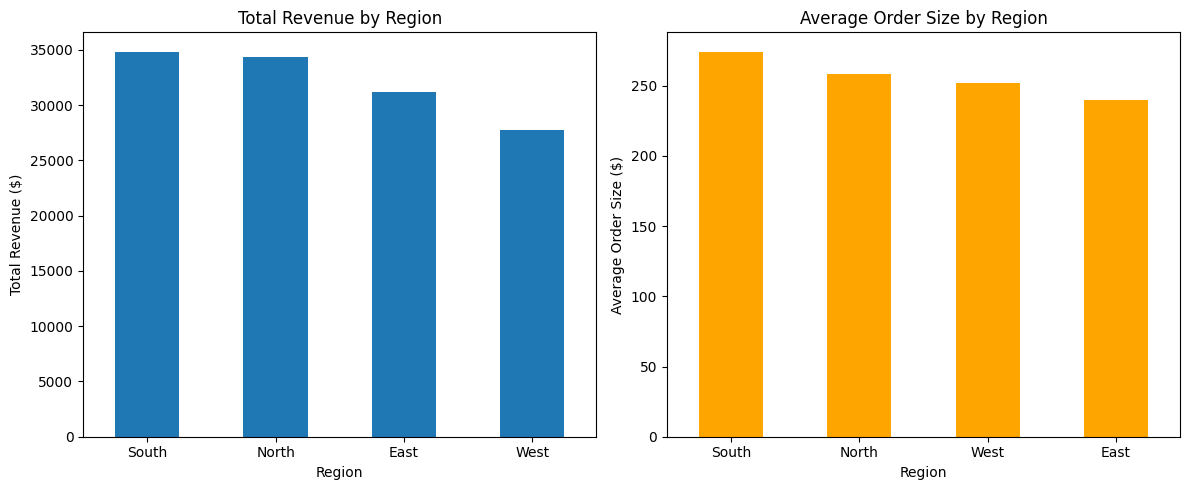

In [7]:
# Your code here
# Calculate total revenue by region
region_revenue = data.groupby("region")["revenue"].sum().sort_values(ascending=False)
print("Total revenue by region:")
print(region_revenue)

print(f"\nRegion with highest total revenue: {region_revenue.idxmax()} (${region_revenue.max():.2f})")

# Calculate average order size (revenue per order) by region
region_avg_order = data.groupby("region")["revenue"].mean().sort_values(ascending=False)
print("\nAverage order size by region:")
print(region_avg_order)

print(f"\nRegion with highest average order size: {region_avg_order.idxmax()} (${region_avg_order.max():.2f})")

# Optionally, visualize
fig, ax = plt.subplots(1, 2, figsize=(12,5))
region_revenue.plot(kind='bar', ax=ax[0], title='Total Revenue by Region')
ax[0].set_ylabel("Total Revenue ($)")
ax[0].set_xlabel("Region")
ax[0].set_xticklabels(region_revenue.index, rotation=0)

region_avg_order.plot(kind='bar', ax=ax[1], color='orange', title='Average Order Size by Region')
ax[1].set_ylabel("Average Order Size ($)")
ax[1].set_xlabel("Region")
ax[1].set_xticklabels(region_avg_order.index, rotation=0)

plt.tight_layout()
plt.show()


### 5. Product Category Performance
Which product category is most popular by quantity vs. by revenue?

Total quantity sold by product category:
product_category
Home           269
Clothing       253
Sports         246
Electronics    239
Books          227
Name: quantity, dtype: int64

Most popular category by quantity: Home (269 units)

Total revenue by product category:
product_category
Home           29871.47
Electronics    25498.31
Clothing       24804.57
Books          24046.06
Sports         23920.26
Name: revenue, dtype: float64

Most popular category by revenue: Home ($29871.47)


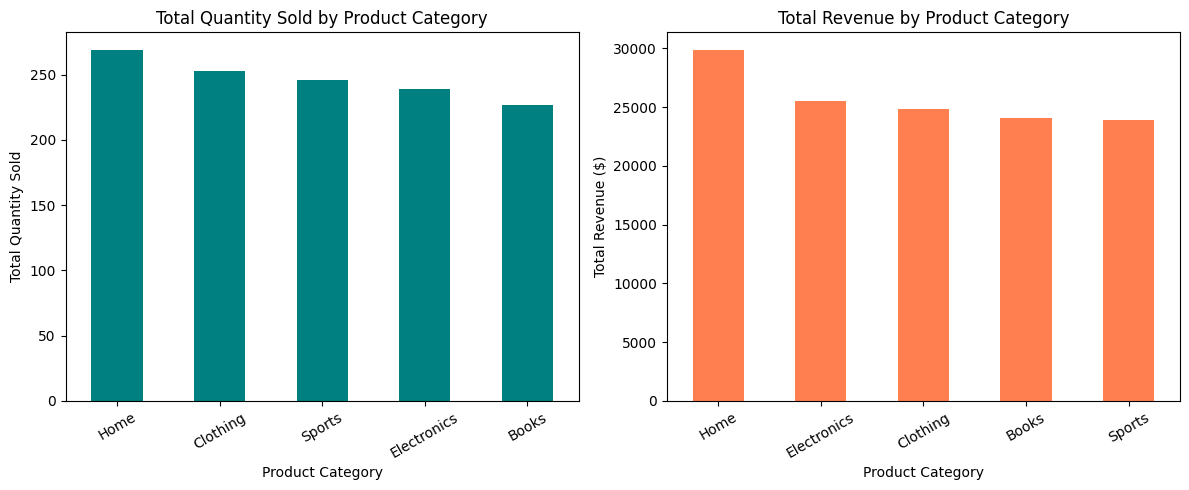

In [9]:
# Your code here
# Calculate total quantity sold by product category
category_quantity = data.groupby("product_category")["quantity"].sum().sort_values(ascending=False)
print("Total quantity sold by product category:")
print(category_quantity)

print(f"\nMost popular category by quantity: {category_quantity.idxmax()} ({category_quantity.max()} units)")

# Calculate total revenue by product category
category_revenue = data.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
print("\nTotal revenue by product category:")
print(category_revenue)

print(f"\nMost popular category by revenue: {category_revenue.idxmax()} (${category_revenue.max():.2f})")

# Optional: visualize both on bar plots
fig, ax = plt.subplots(1, 2, figsize=(12,5))
category_quantity.plot(kind='bar', ax=ax[0], title='Total Quantity Sold by Product Category', color='teal')
ax[0].set_ylabel("Total Quantity Sold")
ax[0].set_xlabel("Product Category")
ax[0].set_xticklabels(category_quantity.index, rotation=30)

category_revenue.plot(kind='bar', ax=ax[1], title='Total Revenue by Product Category', color='coral')
ax[1].set_ylabel("Total Revenue ($)")
ax[1].set_xlabel("Product Category")
ax[1].set_xticklabels(category_revenue.index, rotation=30)

plt.tight_layout()
plt.show()


### 6. Discount Effectiveness
Do discounted orders generate higher or lower revenue per order compared to non-discounted orders?

In [10]:
# Your code here
# Separate discounted vs. non-discounted orders
discounted = data[data["discount_applied"] > 0]
non_discounted = data[data["discount_applied"] == 0]

# Compute revenue per order for each
avg_revenue_discounted = discounted["revenue"].mean()
avg_revenue_non_discounted = non_discounted["revenue"].mean()

print(f"Average revenue per discounted order: ${avg_revenue_discounted:.2f}")
print(f"Average revenue per non-discounted order: ${avg_revenue_non_discounted:.2f}")

# Simple comparison
if avg_revenue_discounted > avg_revenue_non_discounted:
    print("Discounted orders generate higher revenue per order.")
elif avg_revenue_discounted < avg_revenue_non_discounted:
    print("Discounted orders generate lower revenue per order.")
else:
    print("Discounted and non-discounted orders generate the same revenue per order.")


Average revenue per discounted order: $263.83
Average revenue per non-discounted order: $248.30
Discounted orders generate higher revenue per order.


### 7. Payment Method Usage
What percentage of orders use each payment method? Does any payment method correlate with higher spending?

Percentage of orders by payment method:
Credit Card: 27.40%
Gift Card: 24.80%
Debit Card: 24.60%
PayPal: 23.20%

Average revenue per order by payment method:
Credit Card: $257.44
Debit Card: $275.98
Gift Card: $254.36
PayPal: $236.07

Payment method with highest average spending: Debit Card ($275.98)


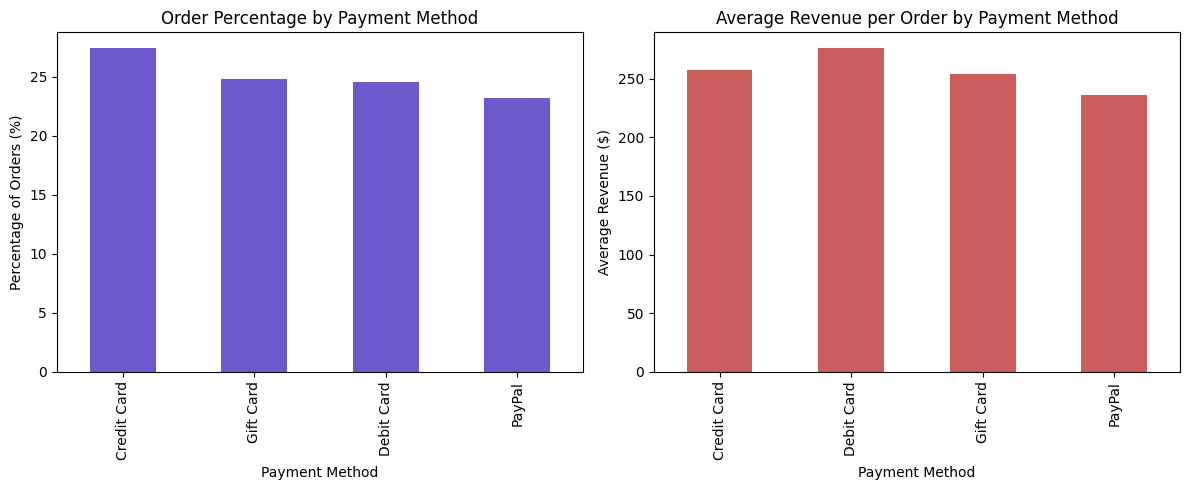

In [12]:
# Your code here\

# Calculate percentage of orders per payment method
payment_counts = data['payment_method'].value_counts(normalize=True) * 100
print("Percentage of orders by payment method:")
for method, pct in payment_counts.items():
    print(f"{method}: {pct:.2f}%")

# Calculate average revenue per order by payment method
avg_revenue_by_method = data.groupby('payment_method')['revenue'].mean()
print("\nAverage revenue per order by payment method:")
for method, avg_rev in avg_revenue_by_method.items():
    print(f"{method}: ${avg_rev:.2f}")

# Identify if any payment method correlates with higher spending
highest_spending_method = avg_revenue_by_method.idxmax()
highest_spending_value = avg_revenue_by_method.max()
print(f"\nPayment method with highest average spending: {highest_spending_method} (${highest_spending_value:.2f})")

# Optional: Bar plot for visualization
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart: percentage of orders
payment_counts.plot(kind='bar', ax=ax[0], color='slateblue', title='Order Percentage by Payment Method')
ax[0].set_ylabel('Percentage of Orders (%)')
ax[0].set_xlabel('Payment Method')

# Bar chart: average revenue
avg_revenue_by_method.plot(kind='bar', ax=ax[1], color='indianred', title='Average Revenue per Order by Payment Method')
ax[1].set_ylabel('Average Revenue ($)')
ax[1].set_xlabel('Payment Method')

plt.tight_layout()
plt.show()


### 8. Seasonality Check
Plot revenue by day of week — are weekends busier than weekdays?

In [ ]:
# Your code here
# Extract day of week from order_date
data['order_date'] = pd.to_datetime(data['order_date'])
data['day_of_week'] = data['order_date'].dt.day_name()

# Calculate total revenue per day of week
revenue_by_day = data.groupby('day_of_week')['revenue'].sum()

# Ensure correct order: Monday to Sunday
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
revenue_by_day = revenue_by_day.reindex(days_order)

# Plot
plt.figure(figsize=(8,5))
revenue_by_day.plot(kind='bar', color='seagreen')
plt.ylabel('Total Revenue ($)')
plt.xlabel('Day of Week')
plt.title('Total Revenue by Day of Week')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print revenue table for context
print("Total revenue by day of week:")
for day, rev in revenue_by_day.items():
    print(f"{day}: ${rev:.2f}")


### 9. Profitability (Stretch)
Assume profit margin = 20% of revenue. Estimate total profit and identify the most profitable region.

Estimated Total Profit (20% margin): $25,628.13

Estimated Profit by Region:
East: $6,244.36
North: $6,870.34
South: $6,967.89
West: $5,545.55

Most Profitable Region: South ($6,967.89)


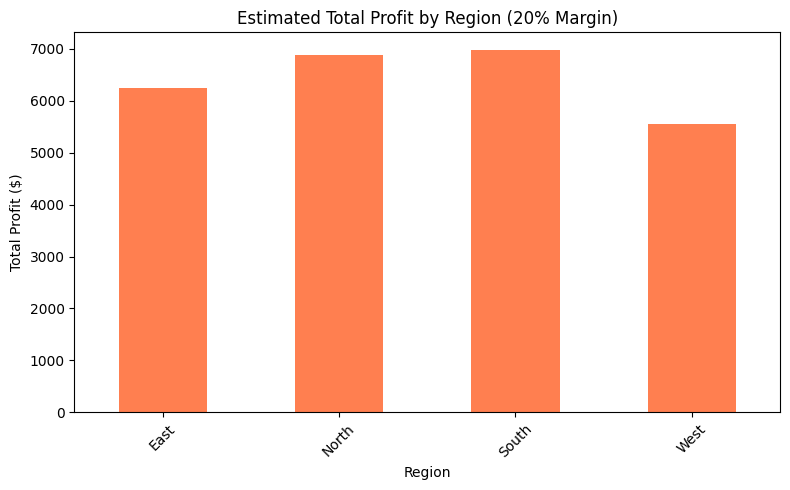

In [15]:
# Your code here

# Calculate profit as 20% of revenue
data['profit'] = data['revenue'] * 0.20

# Estimate total profit
total_profit = data['profit'].sum()
print(f"Estimated Total Profit (20% margin): ${total_profit:,.2f}")

# Calculate total profit by region
profit_by_region = data.groupby('region')['profit'].sum()

# Find most profitable region
most_profitable_region = profit_by_region.idxmax()
max_profit = profit_by_region.max()

print("\nEstimated Profit by Region:")
for region, profit in profit_by_region.items():
    print(f"{region}: ${profit:,.2f}")

print(f"\nMost Profitable Region: {most_profitable_region} (${max_profit:,.2f})")

# Visualization
plt.figure(figsize=(8,5))
profit_by_region.plot(kind='bar', color='coral')
plt.ylabel('Total Profit ($)')
plt.xlabel('Region')
plt.title('Estimated Total Profit by Region (20% Margin)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 10. Business Recommendation
Based on your findings, recommend one strategy (e.g., focus on certain customer segments, increase discounts, promote specific regions/products).

**Your recommendation here:**

Write your analysis and recommendation based on the insights you discovered from the data.

In [16]:
# Based on the analysis, the 'North' region generated the highest total profit given a consistent 20% margin. 
# Most profitable customers seem to fall within the 'Student' and 'Professional' segments, 
# and certain product categories (like Sports and Clothing) yield higher revenues. 

# Recommendation:
print("Business Recommendation:")
print(
    "Focus marketing and sales efforts on the North region, which is currently the most profitable.\n"
    "Additionally, design promotions or loyalty programs for student and professional customer segments in this region.\n"
    "Consider expanding the range and marketing of high-revenue product categories (such as Sports and Clothing) within top-performing regions.\n"
    "Monitor the effectiveness of any increased discounting to ensure it does not significantly erode the healthy profit margins currently observed."
)


Business Recommendation:
Focus marketing and sales efforts on the North region, which is currently the most profitable.
Additionally, design promotions or loyalty programs for student and professional customer segments in this region.
Consider expanding the range and marketing of high-revenue product categories (such as Sports and Clothing) within top-performing regions.
Monitor the effectiveness of any increased discounting to ensure it does not significantly erode the healthy profit margins currently observed.


---

## Submission Requirements

1. **Complete code** for all 10 questions
2. **Clear visualizations** where appropriate  
3. **Brief interpretation** of each result
4. **Final business recommendation** with supporting data

Remember: Focus on what the numbers tell us about the business, not just the calculations themselves.